# Wave Boundary Tutorial

This tutorial covers wave boundary conditions in `rompy-xbeach`. XBeach needs
wave forcing at the offshore boundary, and rompy-xbeach provides flexible ways
to specify these conditions.

## What You'll Learn

1. Non-spectral boundaries (simple parametric waves)
2. Data-driven spectral boundaries (generate from data sources)
3. File-based spectral boundaries (use pre-existing files)
4. Special boundary types (off, reuse)

## Prerequisites

- Familiarity with the `RegularGrid` class (see **Grid Tutorial**)
- Understanding of data sources (see **Source Tutorial**)

## Helper Functions

In [1]:
def print_params(params: dict, filename: str = "params.txt"):
    """Display parameters in a text-editor style format."""
    border = "─" * 60
    print(f"┌{border}┐")
    print(f"│ {filename:<58} │")
    print(f"├{border}┤")
    for k, v in params.items():
        line = f"{k} = {v}"
        print(f"│ {line:<58} │")
    print(f"└{border}┘")


def print_file(filepath, title=None):
    """Display file contents in a text-editor style format."""
    border = "─" * 60
    title = title or filepath.name
    print(f"┌{border}┐")
    print(f"│ {title:<58} │")
    print(f"├{border}┤")
    for line in filepath.read_text().strip().split("\n"):
        # Truncate long lines
        if len(line) > 58:
            line = line[:55] + "..."
        print(f"│ {line:<58} │")
    print(f"└{border}┘")

---
## Overview

### Boundary Type Categories

| Category | Types | Description |
|----------|-------|-------------|
| **Non-spectral** | `stat`, `bichrom`, `stat_table`, `ts_1`, `ts_2` | Bulk parameters only |
| **Spectral** | `jons`, `jonstable`, `swan`, `vardens` | Full spectral information |
| **Special** | `off`, `reuse` | No waves or reuse previous files |

In [2]:
from pathlib import Path
import xarray as xr
import warnings
warnings.filterwarnings("ignore")

from rompy.core.time import TimeRange
from rompy_xbeach.grid import RegularGrid
from rompy_xbeach.source import SourceCRSFile, SourceCRSWavespectra

# Setup paths
HERE = Path("/source/csiro/rompy-xbeach/tests")
DATA_DIR = HERE / "data"
OUT_DIR = Path("wave-boundary-tutorial")
OUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUT_DIR}")

Data directory: /source/csiro/rompy-xbeach/tests/data
Output directory: wave-boundary-tutorial


### Common Setup

Define grid and data sources used throughout this tutorial.

In [3]:
# Model grid
grid = RegularGrid(
    ori=dict(x=115.594239, y=-32.641104, crs="epsg:4326"),
    alfa=347.0,
    dx=10, dy=15,
    nx=230, ny=220,
    crs="28350",
)

# Data sources for data-driven examples
source_spectra = SourceCRSWavespectra(
    uri=DATA_DIR / "aus-20230101.nc",
    reader="read_ww3",
)

source_param = SourceCRSFile(
    uri=DATA_DIR / "smc-params-20230101.nc",
    crs=4326,
    x_dim="lon",
    y_dim="lat",
)

source_gridded_param = source = SourceCRSFile(
    uri=DATA_DIR / "gridded_wave_parameters.nc",
    crs=4326,
    x_dim="longitude",
    y_dim="latitude",
)

# Time ranges
times_spectra = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")
times_param = TimeRange(start="2023-01-01T00", end="2023-01-01T03", interval="1h")
times_gridded_param = TimeRange(start="2023-01-01T00", end="2023-01-02T00", interval="1h")

print(f"Grid: {grid.nx}x{grid.ny} cells")

Grid: 230x220 cells


---
# Part 1: Non-Spectral Boundaries (Simple Cases)

These are the simplest boundary types - some don't even need files!

## 1.1 Stationary Waves (`stat`)

Define constant wave conditions using bulk parameters. No file needed.

In [4]:
from rompy_xbeach.data.boundary import BoundaryStat

boundary = BoundaryStat(
    Hrms=2.0,      # Wave height (m)
    Trep=12.0,     # Period (s)
    dir0=270.0,    # Direction from North (degrees)
    m=10,          # Directional spreading power
)

params = boundary.get(destdir=OUT_DIR, grid=grid, time=times_param)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = stat                                             │
│ Hrms = 2.0                                                 │
│ Trep = 12.0                                                │
│ dir0 = 270.0                                               │
│ m = 10                                                     │
└────────────────────────────────────────────────────────────┘


## 1.2 Bichromatic Waves (`bichrom`)

Two-frequency wave groups. No file needed.

In [5]:
from rompy_xbeach.data.boundary import BoundaryBichrom

boundary = BoundaryBichrom(
    Hrms=1.5,
    Trep=10.0,
    Tlong=80.0,    # Wave group period (s)
    dir0=270.0,
    m=10,
)

params = boundary.get(destdir=OUT_DIR, grid=grid, time=times_param)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = bichrom                                          │
│ Hrms = 1.5                                                 │
│ Trep = 10.0                                                │
│ Tlong = 80.0                                               │
│ dir0 = 270.0                                               │
│ m = 10                                                     │
└────────────────────────────────────────────────────────────┘


## 1.3 No Wave Forcing (`off`)

For tide-only or current-only simulations.

In [6]:
from rompy_xbeach.data.boundary import BoundaryOff

boundary = BoundaryOff()
params = boundary.get(destdir=OUT_DIR, grid=grid, time=times_param)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = off                                              │
└────────────────────────────────────────────────────────────┘


---
# Part 2: Data-Driven Spectral Boundaries

Generate boundary files automatically from data sources. This is the most
common approach when you have model output or observations.

## Naming Convention

Classes follow the pattern: `Boundary{DataStructure}{DataType}{Bctype}`

- **DataStructure**: `Station`, `Grid`, or `Point`
- **DataType**: `Spectra` or `Param`
- **Bctype**: `Jons`, `Jonstable`, `Swan`

## 2.1 JONSWAP from Station Spectra (`BoundaryStationSpectraJons`)

Generate JONSWAP files from full 2D wave spectra.

### Single File (Constant Conditions) - Default

By default (`filelist=False`), a single bcfile is created at `time.start` and used
for the entire simulation.

In [7]:
from rompy_xbeach.data.boundary import BoundaryGridParamJonstable


In [8]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraJons

destdir = OUT_DIR / "jons_spectra_single"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationSpectraJons(
    source=source_spectra,
    # filelist=False is the default
    dtbc=2.0,       # Timestep for generated wave timeseries
    fnyq=0.3,       # Nyquist frequency
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

list(destdir.glob("*.txt"))

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-20230101T000000.txt                          │
│ dtbc = 2.0                                                 │
└────────────────────────────────────────────────────────────┘


[PosixPath('wave-boundary-tutorial/jons_spectra_single/jons-20230101T000000.txt')]

In [9]:
# Only one file created (no filelist)

list(destdir.glob("*.txt"))

[PosixPath('wave-boundary-tutorial/jons_spectra_single/jons-20230101T000000.txt')]

In [10]:
# Inspect the bcfile content

bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jons-20230101T000000.txt                                   │
├────────────────────────────────────────────────────────────┤
│ Hm0 = 0.451453                                             │
│ mainang = 44.6871                                          │
│ gammajsp = 2.37594                                         │
│ s = 66.9335                                                │
│ Tp = 14.3738                                               │
│ fnyq = 0.3                                                 │
└────────────────────────────────────────────────────────────┘


### Multiple Files (Time-Varying)

Set `filelist=True` to create multiple bcfiles, one per timestep in the source data.

In [11]:
destdir = OUT_DIR / "jons_spectra_multi"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationSpectraJons(
    source=source_spectra,
    filelist=True,  # Create multiple files
    coords=dict(x="lon", y="lat", s="site"),  # Default coordinate names
    dtbc=2.0,       # Timestep for generated wave timeseries
    fnyq=0.3,       # Nyquist frequency
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-filelist.txt                                 │
│ dtbc = 2.0                                                 │
└────────────────────────────────────────────────────────────┘


In [12]:
# The jons-filelist.txt is created in the destdir directory and contains the list of
# bcfiles which are also created in the same workspace. One file is created for each
# time step in the input source data within the time period specified in the time
# parameter (the initial and end times are interpolated at time.start and time.end if
# these exact times are not present in the source dataset).

list(destdir.glob("*.txt"))

[PosixPath('wave-boundary-tutorial/jons_spectra_multi/jons-20230101T000000.txt'),
 PosixPath('wave-boundary-tutorial/jons_spectra_multi/jons-20230101T060000.txt'),
 PosixPath('wave-boundary-tutorial/jons_spectra_multi/jons-filelist.txt')]

In [13]:
# Let's inspect the content of bcfile. Note the duration is defined by the
# time steps in the source dataset which in this test data file is 6h.

filelist = destdir / params["bcfile"]
print_file(filelist)

┌────────────────────────────────────────────────────────────┐
│ jons-filelist.txt                                          │
├────────────────────────────────────────────────────────────┤
│ FILELIST                                                   │
│ 21600 2 jons-20230101T000000.txt                           │
│ 21600 2 jons-20230101T060000.txt                           │
└────────────────────────────────────────────────────────────┘


In [14]:
# And the content of one of the bcfiles

bcfile = destdir / filelist.read_text().split("\n")[1].split()[-1]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jons-20230101T000000.txt                                   │
├────────────────────────────────────────────────────────────┤
│ Hm0 = 0.451453                                             │
│ mainang = 44.6871                                          │
│ gammajsp = 2.37594                                         │
│ s = 66.9335                                                │
│ Tp = 14.3738                                               │
│ fnyq = 0.3                                                 │
└────────────────────────────────────────────────────────────┘


## 2.2 JONSWAP from Station Parameters (`BoundaryStationParamJons`)

Generate JONSWAP from integrated wave parameters (Hm0, Tp, direction, etc.).
Parameter variable names use the `_var` suffix to distinguish them from XBeach params.

### Single File (Default)

In [15]:
from rompy_xbeach.data.boundary import BoundaryStationParamJons

destdir = OUT_DIR / "jons_param_single"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationParamJons(
    source=source_param,
    coords=dict(s="seapoint", x="longitude", y="latitude", t="time"),
    hm0_var="phs1",        # Variable name for Hm0
    tp_var="ptp1",         # Variable name for Tp
    mainang_var="pdp1",    # Variable name for direction
    gammajsp_var="ppe1",   # Variable name for gamma
    dspr_var="pspr1",      # Variable name for spreading
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_param)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-20230101T000000.txt                          │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


In [16]:
bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jons-20230101T000000.txt                                   │
├────────────────────────────────────────────────────────────┤
│ Hm0 = 0.875435                                             │
│ mainang = 254.158                                          │
│ gammajsp = 2.68225                                         │
│ s = 21.9514                                                │
│ Tp = 13.1659                                               │
└────────────────────────────────────────────────────────────┘


### Multiple Files (Time-Varying)

In [17]:
destdir = OUT_DIR / "jons_param_multi"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationParamJons(
    source=source_param,
    filelist=True,  # Create multiple files
    coords=dict(s="seapoint"),
    hm0_var="phs1",
    tp_var="ptp1",
    mainang_var="pdp1",
    gammajsp_var="ppe1",
    dspr_var="pspr1",
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_param)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-filelist.txt                                 │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


In [18]:
# List generated files

list(destdir.glob("*.txt"))

[PosixPath('wave-boundary-tutorial/jons_param_multi/jons-20230101T000000.txt'),
 PosixPath('wave-boundary-tutorial/jons_param_multi/jons-20230101T020000.txt'),
 PosixPath('wave-boundary-tutorial/jons_param_multi/jons-20230101T010000.txt'),
 PosixPath('wave-boundary-tutorial/jons_param_multi/jons-filelist.txt')]

In [19]:
# Inspect the filelist

filelist = destdir / params["bcfile"]
print_file(filelist)

┌────────────────────────────────────────────────────────────┐
│ jons-filelist.txt                                          │
├────────────────────────────────────────────────────────────┤
│ FILELIST                                                   │
│ 3600 1 jons-20230101T000000.txt                            │
│ 3600 1 jons-20230101T010000.txt                            │
│ 3600 1 jons-20230101T020000.txt                            │
└────────────────────────────────────────────────────────────┘


### Mixing Data Variables with Constants

You can use variable names for some parameters and constant values for others:

In [20]:
destdir = OUT_DIR / "jons_param_mixed"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationParamJons(
    source=source_param,
    coords=dict(s="seapoint"),
    hm0_var="phs1",        # From data
    tp_var="ptp1",         # From data
    mainang_var="pdp1",    # From data
    gammajsp_var=3.3,      # Constant value
    dspr_var=20.0,         # Constant value (degrees)
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_param)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-20230101T000000.txt                          │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


In [21]:
bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jons-20230101T000000.txt                                   │
├────────────────────────────────────────────────────────────┤
│ Hm0 = 0.875435                                             │
│ mainang = 254.158                                          │
│ gammajsp = 3.3                                             │
│ s = 15.414                                                 │
│ Tp = 13.1659                                               │
└────────────────────────────────────────────────────────────┘


**Note**: `dspr_var` (directional spreading in degrees) is converted to the JONSWAP
spreading coefficient `s` internally.

## 2.3 JONSTABLE from Station Spectra (`BoundaryStationSpectraJonstable`)

Generate a JONSWAP table with time-varying parameters in a single file.

In [22]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraJonstable

destdir = OUT_DIR / "jonstable_spectra"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationSpectraJonstable(source=source_spectra)
params = wbdata.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jonstable                                        │
│ bcfile = jonstable-20230101T000000-20230101T120000.txt     │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


In [23]:
# Inspect the table content

bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jonstable-20230101T000000-20230101T120000.txt              │
├────────────────────────────────────────────────────────────┤
│ 0.451453 14.3738 44.6871 2.37594 66.9335 21600 1           │
│ 0.472394 14.4435 44.6857 2.45055 90.0861 21600 1           │
│ 0.490301 14.2813 44.7835 2.38401 48.2725 21600 1           │
└────────────────────────────────────────────────────────────┘


## 2.4 JONSTABLE from Station Parameters (`BoundaryStationParamJonstable`)

In [24]:
from rompy_xbeach.data.boundary import BoundaryStationParamJonstable

destdir = OUT_DIR / "jonstable_param"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationParamJonstable(
    source=source_param,
    coords=dict(s="seapoint"),
    hm0_var="phs1",
    tp_var="ptp1",
    mainang_var="pdp1",
    gammajsp_var="ppe1",
    dspr_var="pspr1",
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_param)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jonstable                                        │
│ bcfile = jonstable-20230101T000000-20230101T030000.txt     │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


In [25]:
bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ jonstable-20230101T000000-20230101T030000.txt              │
├────────────────────────────────────────────────────────────┤
│ 0.875435 13.1659 254.158 2.68225 21.9514 3600 1            │
│ 0.909496 13.1292 254.18 2.71106 22.1417 3600 1             │
│ 0.802303 14.8497 258.658 3.33514 37.515 3600 1             │
│ 0.869525 14.4893 258.572 3.04059 32.5684 3600 1            │
└────────────────────────────────────────────────────────────┘


## 2.5 Jonstable from gridded parameters (`BoundaryGridParamJonstable`)


In [26]:
from rompy_xbeach.data.boundary import BoundaryGridParamJonstable

destdir = OUT_DIR / "jonstable_gridded_param"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryGridParamJonstable(
    source=source_gridded_param,
    hm0_var="phs1",     # Use the appropriate Hs parameter in your file
    tp_var="ptp1",      # Use the appropriate Tp parameter in your file
    mainang_var="pdp1", # Use the appropriate Dpm parameter in your file
    gammajsp_var=3.3,   # Or use from the appropriate variable in your file
    dspr_var=30,        # Or use from the appropriate variable in your file
    dtbc=2.0,           # Timestep for generated wave timeseries
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_gridded_param)
print_params(params)

bcfile = destdir / params["bcfile"]
print_file(bcfile)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jonstable                                        │
│ bcfile = jonstable-20230101T000000-20230102T000000.txt     │
│ dtbc = 2.0                                                 │
└────────────────────────────────────────────────────────────┘
┌────────────────────────────────────────────────────────────┐
│ jonstable-20230101T000000-20230102T000000.txt              │
├────────────────────────────────────────────────────────────┤
│ 0.59286 15.326 256.055 3.3 6.29513 3600 2                  │
│ 0.634844 15.24 256.115 3.3 6.29513 3600 2                  │
│ 0.676148 15.1233 255.98 3.3 6.29513 3600 2                 │
│ 0.701835 16.1724 259.39 3.3 6.29513 3600 2                 │
│ 0.759703 15.9682 259.123 3.3 6.29513 3600 2                │
│ 0.873939 15.734 258.396 3.3 6.29513 3600 2           

## 2.6 SWAN 2D Spectra from Station Data (`BoundaryStationSpectraSwan`)

Generate full 2D spectral files in SWAN format.

In [27]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraSwan
from wavespectra import read_swan

### Single File (Default)

In [28]:
destdir = OUT_DIR / "swan_spectra_single"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationSpectraSwan(
    source=source_spectra,
    # filelist=False is the default
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = swan                                             │
│ bcfile = swan-20230101T000000.txt                          │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


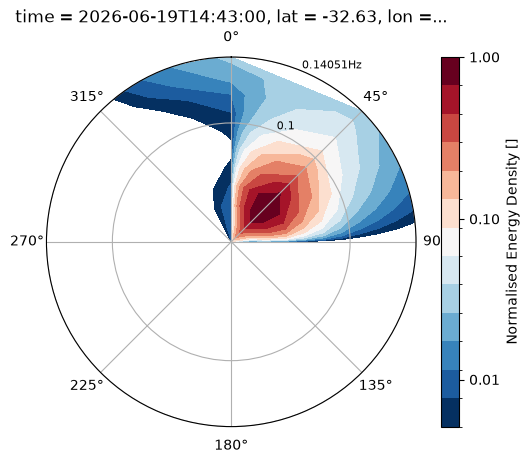

In [29]:
# Read and plot the spectrum

bcfile = destdir / params["bcfile"]
dset = read_swan(bcfile)
dset.squeeze().spec.plot()

### Multiple Files (Time-Varying)

In [30]:
destdir = OUT_DIR / "swan_spectra_multi"
destdir.mkdir(exist_ok=True)

wbdata = BoundaryStationSpectraSwan(
    source=source_spectra,
    filelist=True,  # Create multiple files
)

params = wbdata.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = swan                                             │
│ bcfile = swan-filelist.txt                                 │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


In [31]:
# List generated files

list(destdir.glob("*.txt"))

[PosixPath('wave-boundary-tutorial/swan_spectra_multi/swan-20230101T000000.txt'),
 PosixPath('wave-boundary-tutorial/swan_spectra_multi/swan-20230101T060000.txt'),
 PosixPath('wave-boundary-tutorial/swan_spectra_multi/swan-filelist.txt')]

In [32]:
# Inspect the filelist

filelist = destdir / params["bcfile"]
print_file(filelist)

┌────────────────────────────────────────────────────────────┐
│ swan-filelist.txt                                          │
├────────────────────────────────────────────────────────────┤
│ FILELIST                                                   │
│ 21600 1 swan-20230101T000000.txt                           │
│ 21600 1 swan-20230101T060000.txt                           │
└────────────────────────────────────────────────────────────┘


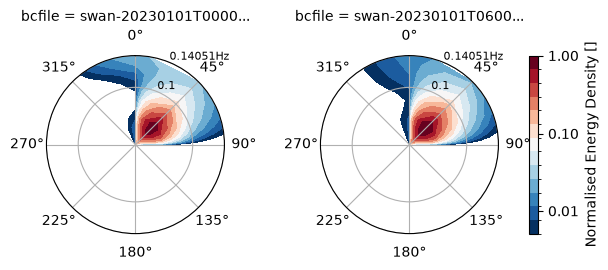

In [33]:
# Read and plot all spectra

bcfiles = [row.split()[-1] for row in filelist.read_text().split("\n")[1:-1]]
dset = xr.concat([read_swan(destdir / f).squeeze() for f in bcfiles], dim="bcfile")
dset["bcfile"] = bcfiles
dset.spec.plot(col="bcfile", col_wrap=2)

---
# Part 3: File-Based Spectral Boundaries

Use pre-existing boundary files. We'll use files generated in Part 2 to
demonstrate this approach.

## 3.1 JONSWAP from File (`BoundaryFileJons`)

Point to existing JONSWAP file(s).

In [34]:
from rompy_xbeach.data.boundary import BoundaryFileJons
from rompy_xbeach.types import XBeachDataBlob

### Single File (Default)

Use a single JONSWAP file we generated earlier:

In [35]:
# Use the single JONSWAP file we created earlier
source_file = OUT_DIR / "jons_spectra_single" / "jons-20230101T000000.txt"

destdir = OUT_DIR / "file_jons_single"
destdir.mkdir(exist_ok=True)

boundary = BoundaryFileJons(
    bcfile_source=XBeachDataBlob(source=source_file),
    # filelist=False is the default
)

params = boundary.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-20230101T000000.txt                          │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


In [36]:
# The file is copied to destdir

list(destdir.glob("*.txt"))

[PosixPath('wave-boundary-tutorial/file_jons_single/jons-20230101T000000.txt')]

### Multiple Files (Filelist)

Use a filelist pointing to multiple JONSWAP files:

In [37]:
# Use the filelist we created earlier
source_filelist = OUT_DIR / "jons_spectra_multi" / "jons-filelist.txt"

destdir = OUT_DIR / "file_jons_multi"
destdir.mkdir(exist_ok=True)

boundary = BoundaryFileJons(
    bcfile_source=XBeachDataBlob(source=source_filelist),
    filelist=True,  # Source is a filelist
)

params = boundary.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jons                                             │
│ bcfile = jons-filelist.txt                                 │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


## 3.2 JONSTABLE from File (`BoundaryFileJonstable`)

In [38]:
from rompy_xbeach.data.boundary import BoundaryFileJonstable

# Use the jonstable file we created earlier
source_file = list((OUT_DIR / "jonstable_spectra").glob("jonstable-*.txt"))[0]

destdir = OUT_DIR / "file_jonstable"
destdir.mkdir(exist_ok=True)

boundary = BoundaryFileJonstable(
    bcfile_source=XBeachDataBlob(source=source_file),
)

params = boundary.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = jonstable                                        │
│ bcfile = jonstable-20230101T000000-20230101T120000.txt     │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


## 3.3 SWAN Spectra from File (`BoundaryFileSwan`)

In [39]:
from rompy_xbeach.data.boundary import BoundaryFileSwan

# Use the SWAN file we created earlier
source_file = list((OUT_DIR / "swan_spectra_single").glob("swan-*.txt"))[0]

destdir = OUT_DIR / "file_swan"
destdir.mkdir(exist_ok=True)

boundary = BoundaryFileSwan(
    bcfile_source=XBeachDataBlob(source=source_file),
    # filelist=False is the default
)

params = boundary.get(destdir=destdir, grid=grid, time=times_spectra)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ wbctype = swan                                             │
│ bcfile = swan-20230101T000000.txt                          │
│ dtbc = 1.0                                                 │
└────────────────────────────────────────────────────────────┘


---
# Part 4: Reusing Previous Boundary Files

For chained simulations, you can reuse boundary files from a previous run.

In [40]:
from rompy_xbeach.data.boundary import BoundaryReuse

# boundary = BoundaryReuse(
#     previous_run=XBeachDirectoryBlob(source="/path/to/previous/run"),
# )

print("BoundaryReuse: Reuse ebcflist.bcf and qbcflist.bcf from previous run")
print("  - Copies required files to new run directory")
print("  - Useful for chained simulations")

BoundaryReuse: Reuse ebcflist.bcf and qbcflist.bcf from previous run
  - Copies required files to new run directory
  - Useful for chained simulations


---
# Part 5: Using in Config

All boundary classes are used via `Config.input.wave`.

In [41]:
from rompy_xbeach.config import Config, DataInterface
from rompy_xbeach.data.bathy import XBeachBathy

# Create bathymetry
bathy = XBeachBathy(
    source={"model_type": "geotiff", "filename": str(DATA_DIR / "bathy.tif")}
)

### Example: Stationary Waves

In [42]:
config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(
        wave=BoundaryStat(Hrms=2.0, Trep=12.0, dir0=270.0),
    ),
)

print("Config with stationary waves:")
print(f"  Wave type: {config.input.wave.id}")

Config with stationary waves:
  Wave type: stat


### Example: Data-Driven JONSWAP

In [43]:
config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(
        wave=BoundaryStationParamJons(
            source=source_param,
            coords=dict(s="seapoint"),
            hm0_var="phs1",
            tp_var="ptp1",
            mainang_var="pdp1",
            gammajsp_var=3.3,
            dspr_var=20.0,
        ),
    ),
)

print("Config with data-driven JONSWAP:")
print(f"  Wave type: {config.input.wave.id}")
print(f"  Source: {config.input.wave.source.uri.name}")

Config with data-driven JONSWAP:
  Wave type: jons
  Source: smc-params-20230101.nc


### Example: File-Based JONSWAP

In [44]:
config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(
        wave=BoundaryFileJons(
            bcfile_source=XBeachDataBlob(source=source_file),
        ),
    ),
)

print("Config with file-based JONSWAP:")
print(f"  Wave type: {config.input.wave.id}")

Config with file-based JONSWAP:
  Wave type: jons


---
# Summary

## Boundary Type Quick Reference

| Class | Type | Files | Use Case |
|-------|------|-------|----------|
| `BoundaryStat` | `stat` | None | Simple constant waves |
| `BoundaryBichrom` | `bichrom` | None | Wave groups |
| `BoundaryOff` | `off` | None | No waves |
| `BoundaryStationSpectraJons` | `jons` | Generated | From spectral data |
| `BoundaryStationParamJons` | `jons` | Generated | From parameters |
| `BoundaryStationSpectraJonstable` | `jonstable` | Generated | Time-varying table |
| `BoundaryStationParamJonstable` | `jonstable` | Generated | From parameters |
| `BoundaryStationSpectraSwan` | `swan` | Generated | Full 2D spectra |
| `BoundaryFileJons` | `jons` | Existing | Pre-made JONSWAP |
| `BoundaryFileJonstable` | `jonstable` | Existing | Pre-made table |
| `BoundaryFileSwan` | `swan` | Existing | Pre-made SWAN spectra |
| `BoundaryReuse` | `reuse` | Previous | Chained simulations |

## Key Points

- **All boundaries** use `Config.input.wave`
- **filelist=False** (default): Single file at start time
- **filelist=True**: Multiple files for time-varying conditions
- **Mix data & constants**: Use variable names or float values for parameters

## Next Steps

- See the **Forcing Tutorial** for wind and tide boundary conditions
- See the **Config Tutorial** for complete model setup